In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

       Dates Products Region  Sales
0 2025-01-01    Phone   East  55758
1 2025-01-02   Tablet  South  82409
2 2025-01-03  Monitor   East  81211
3 2025-01-04    Phone   West  75697
4 2025-01-05    Phone   East  47065
Best Region: South


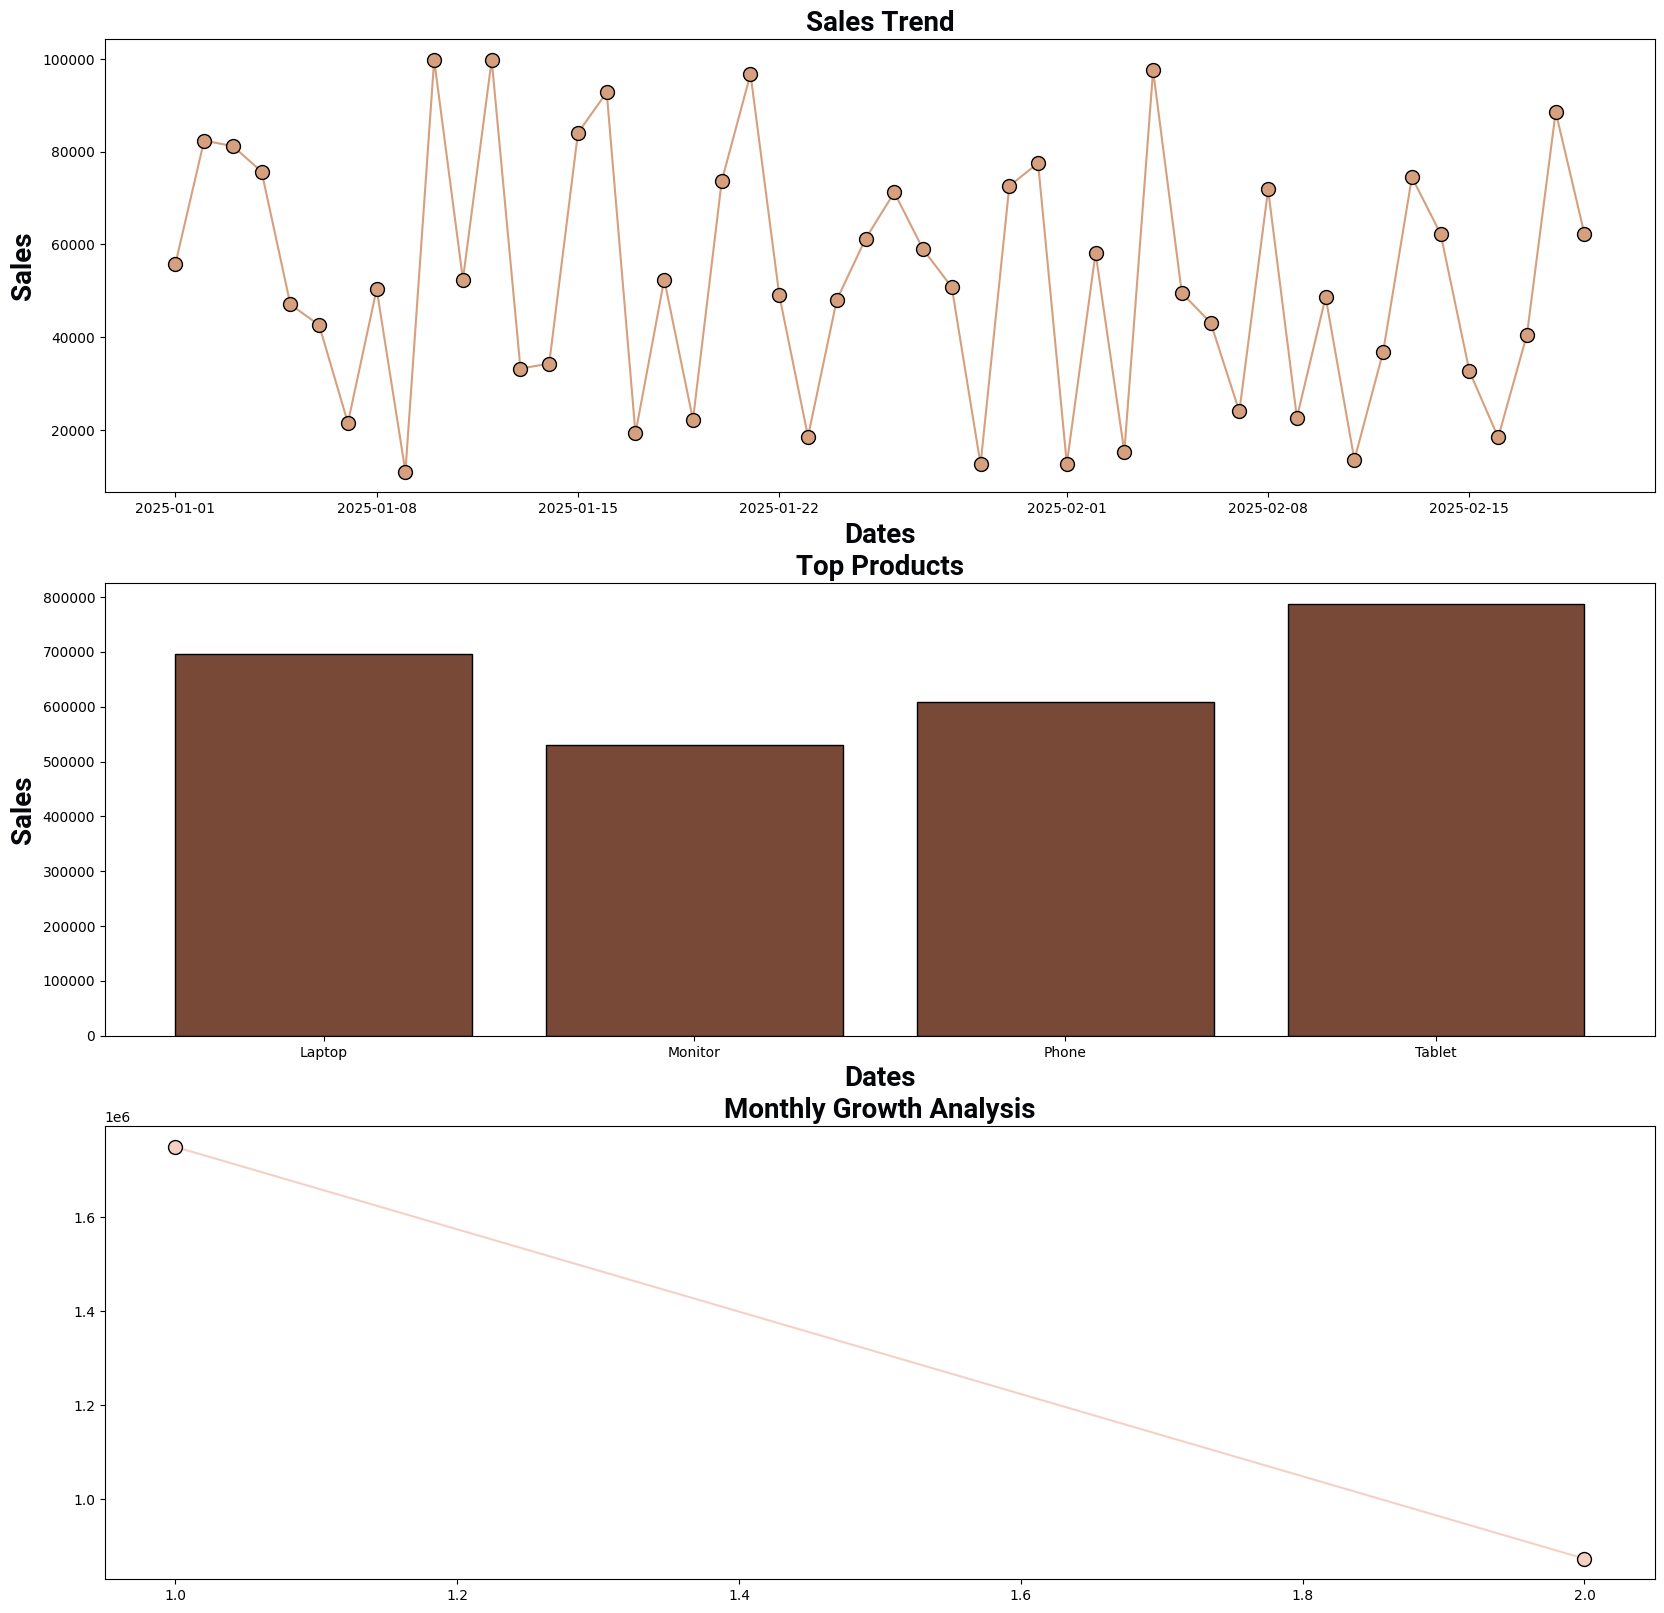

In [71]:
np.random.seed(42)
n = 50
dates = pd.date_range('2025-01-01',periods=n)

products = np.random.choice(['Monitor','Laptop','Phone','Tablet'],n)

region = np.random.choice(['North','South','East','West'],n)

sales = np.random.randint(10000,100000,n)  # np.random.randint(start,finish,total length)


data = {
    "Dates":dates,
    "Products":products,
    "Region":region,
    "Sales":sales
}
df =pd.DataFrame(data)

print(df.head())

# introducing missing values
df.loc[10,'Sales']=np.nan
df.loc[17,'Sales']=np.nan
# handling missing values
df['Sales'] = df['Sales'].fillna(df['Sales'].mean())

# product Sales
p_sales=df.groupby('Products')['Sales'].sum()

# region sales analysis
r_sales = df.groupby("Region")['Sales'].sum()

fig,axes = plt.subplots(3,1,figsize = (20,20))
# line plot
axes[0].plot(df['Dates'],df['Sales'],marker='o',color = '#d69f7e',markeredgecolor ='black',markersize =10)
axes[0].set_title("Sales Trend",fontsize=20,color='#050609',fontweight='bold',family='roboto')
axes[0].set_ylabel("Sales",fontsize=20,color='#050609',fontweight='bold',family='roboto')
axes[0].set_xlabel("Dates",fontsize=20,color='#050609',fontweight='bold',family='roboto')
# bar
axes[1].bar(p_sales.index,p_sales.values,color = '#774936',edgecolor = 'black')
axes[1].set_title("Top Products",fontsize=20,color='#050609',fontweight='bold',family='roboto')
axes[1].set_ylabel("Sales",fontsize=20,color='#050609',fontweight='bold',family='roboto')
axes[1].set_xlabel("Dates",fontsize=20,color='#050609',fontweight='bold',family='roboto')

# Monthly Growth
df['Month']=df['Dates'].dt.month
monthly_sales=df.groupby('Month')['Sales'].sum()
axes[2].plot(monthly_sales.index,monthly_sales.values,marker='o',color = '#f5d0c5',markeredgecolor ='black',markersize =10)
axes[2].set_title("Monthly Growth Analysis",fontsize=20,color='#050609',fontweight='bold',family='roboto')

# Best Region
print("Best Region:",r_sales.idxmax())


# plt.tight_layout()